<b>SENAI/PE – CÓD. 164 PESQUISADOR INDUSTRIAL II (IA Industrial)</b><br>

Estudo de Caso<br>

>> Por Carlos Lima <br>

<p align = 'justify'>O presente Jupyter Notebook é contém o código fonte, a análise e os resultdos referente a prova de conceito no que concerne o <b>Módulo 1: EDA e Classificação de Condição do Motor</b> com o objetivo de Demonstrar fundamentos de análise exploratória de dados industriais, engenharia de features em sinais vibro-acústicos e classificação multiclasse de falhas; e o <b>Módulo 2: Softsensor de Temperatura (Opcional, bônus)</b> com o objetivo de Demonstrar capacidade de construir softsensors industriais, modelos que inferem o valor de uma variável difícil, lenta ou cara de medir a partir de outras variáveis disponíveis..</p>

O referido Jupyter Notebook está estrutura da seguinte forma:

>> 1. Biblioteca e importação de dados <br>
>> 2. Análise Exploratória de Dados <br>
>> 3. Módulo 1: EDA e Classificação de Condição do Motor <br>
>> 4. Módulo 2: Softsensor de Temperatura <br>
>> Conclusão <br>

## 1. Bibliotecas e Importação dos Dados

### 1.1 Importação das Bibliotecas

O primeiro passo é a importação das bibliotecas que serão utilizadas ao longo desta atividade, é importante destacar que não compete a presente atividade uma descrição aprofundada sobre as funcionalidades de cada biblioteca, contudo iremos listar as que serão utilizadas, com uma breve descrição da utilidade de cada uma delas.

*   <b>OS<a href='#id_1'>[1]</a></b>: permite a utilização de diversas funcionalidades do sistema operacional, sendo utilizada para carregamento de arquivos no ambiente do Google Colab, entre outros;
*   <b>Pandas<a href='#id_2'>[2]</a></b>: possibilita de forma simples e flexivel a manipulação de estruturas de dados, com dados de diferentes tipos, que possibilita a análise de dados;
*   <b>Numpy<a href='#id_3'>[3]</a></b>: consiste em uma biblioteca para manipulação de dados em formato de arrays ou matrizes com diversas funções para operações matemáticas e estatísticas;
*   <b>Seaborn<a href='#id_4'>[4]</a></b>: biblioteca de visualização de dados que permitem diversos gráficos e abordagens estatísticas;
*   <b>Matplotlib<a href='#id_5'>[5]</a></b>: biblioteca de visualização que permite criar gráficos interativos ou estatícos, e visualização de dados;
*   <b>Scikit-Learn<a href='#id_6'>[6]</a></b>: uma biblioteca de aprendizado de máquina que suporta aprendizado supervisionado e não supervisionado, com várias ferramentas para ajuste, seleção, avaliação do modelo;

In [46]:
%matplotlib inline

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# scikit learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

### 1.2 Descrição do Conjunto de Dados

O conjunto de dados possuem as seguintes características:

• 16 arquivos CSV, totalizando aproximadamente 310 MB;<br>
• 4 classes de condição do motor, com 4 arquivos por classe;<br>
• 2 velocidades de operação (15 Hz e 45 Hz) e 2 condições de carga (sem carga e com carga) por
classe.<br>
• Cada arquivo contém 420.000 linhas × 5 colunas, correspondendo a 10 segundos de aquisição a 42.000
Hz.<br>

O detalhamento, e o dicionário de dados, pode ser encontrado na pasta docs, disponível neste repositório.

### 1.3 Carregamento dos dados

Todos os arquivos seguem o padrão:

{Letra1}_{Letra2}_{Velocidade}_{Carga}.csv <br>

**Letra 1 — Categoria primária da falha**

| Código | Significado |
| --- | --- |
| **H** | Healthy — Saudável |
| **R** | Rotor |
| **B** | Bowed rotor — Rotor empenado |

**Letra 2 — Subtipo / componente afetado**

| Código | Significado |
| --- | --- |
| **H** | Healthy — Saudável |
| **U** | Unbalance — Desbalanceamento |
| **M** | Misalignment — Desalinhamento |
| **R** | Rotor |


**Velocidade (primeiro número)**
| Código | Velocidade nominal |
| --- | --- |
| **1** | 15 Hz |
| **3** | 45 Hz |

A velocidade é imposta por um inversor de frequência (VFD).<br>
A velocidade mecânica real do rotor em RPM depende do escorregamento do motor de indução.<br>

**Carga (segundo número)**

| Código | Condição |
| --- | --- |
| **0** | Sem carga (unloaded) — eixo livre |
| **1** | Com carga (loaded) — disco com dez parafusos fixados simetricamente |

Vamos realizar o carregamento dos dados em um dataFrame do Pandas.<br>
O primeiro passo é passar para uma variável o caminho da pasta de dados. 

In [2]:
data_path = '../data'

Depois vamos criar uma lista vazia para armazenar cada um dos dataFrames. Isso irá permitir unir (concatenear) os dataFrames posteriormente.

In [3]:
dfs = []

O próximo passo é a criação de uma estrutura de repetição (for each) que permite iterar sobre todos os dataFrames, e armazenar todos eles no lista `dfs` que criamos no passo anterior. <br>
O laço utiliza o método `listdir()` da biblioteca os para percorrer cada item na pasta do `data_path`. Depois há um teste do tipo de arquivo na estrutura `if`, seguido da construção do caminho completo do arquivo com o `os.path.join()`. O `df["filename"]` guarda os nomes dos arquivos, pois os nomes possuem os labels. Em seguida é utilizado o método `append()` para adicionar o dataFrame a lista de arquivos.

In [4]:
for file in os.listdir(data_path):
    if file.endswith('.csv'):
        full_path = os.path.join(data_path, file)
        df = pd.read_csv(full_path)
        df['filename'] = file
        dfs.append(df)

Depois da execução do laço de repetição, vamos unir todos os em único dataFrame.

In [5]:
df_full = pd.concat(dfs, ignore_index=True)

Agora vamos exibir os cinco primeiros registros da estrutura final criada utilizando o método `head()` do Pandas.

In [6]:
df_full.head()

,Accelerometer 1 (m/s^2),Microphone (V),Accelerometer 2 (m/s^2),Accelerometer 3 (m/s^2),Temperature (Celsius),filename
0,0.429166,0.073764,1.009485,-3.826502,29.113221,B_R_1_0.csv
1,0.106767,0.076066,1.944442,-3.213944,29.178990,B_R_1_0.csv
2,-0.247872,0.075408,1.847723,-1.666428,29.178990,B_R_1_0.csv
3,0.783805,0.080012,2.234602,-0.570271,29.113221,B_R_1_0.csv
4,0.429166,0.088234,2.105642,-0.118912,29.409183,B_R_1_0.csv


Podemos observar que os dados foram carregados com sucesso. <br>
A coluna filename possui o nome dos arquivos. Contudo, para explorar os dados, e ter uma estrutura mais robusta que permita aplicação de técnicas de aprendizagem de máquina, vamos separar cada um dos labels em uma coluna.<br>


In [7]:
df_full['Primaria'] = df_full['filename'].str.split('_').str[0]
df_full['Subtipo'] = df_full['filename'].str.split('_').str[1]
df_full['Velocidade'] = df_full['filename'].str.split('_').str[2].astype(int)
df_full['Carga'] = df_full['filename'].str.split('_').str[3].str.replace('.csv', '').astype(int)

Vamos utilizar o método `head()` para reexibir os cinco primeiros registros do dataframe df_full, agora com as novas colunas adicionadas. Isso nos permitirá verificar se a extração das informações do nome do arquivo foi realizada corretamente.

In [8]:
df_full.head()

,Accelerometer 1 (m/s^2),Microphone (V),Accelerometer 2 (m/s^2),Accelerometer 3 (m/s^2),Temperature (Celsius),filename,Primaria,Subtipo,Velocidade,Carga
0,0.429166,0.073764,1.009485,-3.826502,29.113221,B_R_1_0.csv,B,R,1,0
1,0.106767,0.076066,1.944442,-3.213944,29.178990,B_R_1_0.csv,B,R,1,0
2,-0.247872,0.075408,1.847723,-1.666428,29.178990,B_R_1_0.csv,B,R,1,0
3,0.783805,0.080012,2.234602,-0.570271,29.113221,B_R_1_0.csv,B,R,1,0
4,0.429166,0.088234,2.105642,-0.118912,29.409183,B_R_1_0.csv,B,R,1,0


## 2. Análise Exploratória

Nesta seção iremos observar e analisar um pouco mais sobre a estrutura dos dados, entender os tipos de dados existentes, bem como aplicar algumas técnicas da estatística descritiva para melhor compreensão da integridade e a confiabilidade da base dados.

### 2.1 Tipos Dados e Estrutura

Para identificar os tipos de dados existentes valos utilizar o método `info()` do Pandas, que irá nos fornecer as informações de cada tipo de acordo com as colunas existentes.

In [9]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 6720000 entries, 0 to 6719999
Data columns (total 10 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Accelerometer 1 (m/s^2)  float64
 1   Microphone (V)           float64
 2   Accelerometer 2 (m/s^2)  float64
 3   Accelerometer 3 (m/s^2)  float64
 4   Temperature (Celsius)    float64
 5   filename                 str    
 6   Primaria                 object 
 7   Subtipo                  object 
 8   Velocidade               int64  
 9   Carga                    int64  
dtypes: float64(5), int64(2), object(2), str(1)
memory usage: 512.7+ MB


Podemos observar que os dados possuem 6720000 (seis milhões e cetecentos e vinte mil linhas) cada arquivo indivual possuía 420000 (quatrocentos e vinte mil) registros, sendo um total de 16 (dezesseis) o que valida o carregamento dos dados. Os dados são do tipo numérico racionais, texto, e inteiros.

Vamos executar a propriedade ndim, que nos dirá quantas dimensões existem nos dados que foram carregados.

In [10]:
df_full.ndim

2

As dimensões, ou seja, a quantidade de linhas e colunas que existem nos dados são uma medida importante para compreender de que forma precisam ser tratados para o Aprendizado de Máquina. Podemos observar que os dados em questão possuem duas dimensões.<br>

Vamos adiante utilizar propriedade `shape` para entender o tamanho de cada uma dessas dimensões.

In [11]:
df_full.shape

(6720000, 10)

Após a aplicação do método, podemos observar que temos o total 6720000 (seis milhões e cetecentos e vinte mil linhas) linhas e 10 (dez) colunas. 
Esse volume de dados pode ser significativo em alguns casos, ao longo dessa análise, pode haver conjunto de dataFrames menores para evitar operações lentas e consumo excessivo de memória.

Vamos utilizar o laço de repetição for, para exibição de itens vazio na estrutura do dataframe.

In [12]:
for col in df_full.columns:
  n_missing = sum(df_full[col].isnull())
  print(f'Coluna {col}: {n_missing} valores ausentes')

Coluna Accelerometer 1 (m/s^2): 0 valores ausentes
Coluna Microphone (V): 0 valores ausentes
Coluna Accelerometer 2 (m/s^2): 0 valores ausentes
Coluna Accelerometer 3 (m/s^2): 0 valores ausentes
Coluna Temperature (Celsius): 0 valores ausentes
Coluna filename: 0 valores ausentes
Coluna Primaria: 0 valores ausentes
Coluna Subtipo: 0 valores ausentes
Coluna Velocidade: 0 valores ausentes
Coluna Carga: 0 valores ausentes


Pode-se constatar que não há valores ausentes no dataset.

## 3. Módulo 1: EDA e Classificação de Condição do Motor

### 3.1 Estatística Descritiva

Vamos executar um resumo Estatístico utilizando o método describe(), nas colunas selecionadas, que irá trazer um resumo com contagem da quantidade de itens, média de valor, desvio padrão, valores mínimos e máximos, bem como os quartis de 25%, 50% e 75% para cada coluna da base. A função lambda está sendo utilizada para formatar os números com quatro casas decimais após o ponto.

In [13]:
df_full[['Accelerometer 1 (m/s^2)',
         'Microphone (V)',
         'Accelerometer 2 (m/s^2)',
         'Accelerometer 3 (m/s^2)',
         'Temperature (Celsius)']].describe().apply(lambda col: col.map(lambda x: f'{x:.4f}'))

,Accelerometer 1 (m/s^2),Microphone (V),Accelerometer 2 (m/s^2),Accelerometer 3 (m/s^2),Temperature (Celsius)
count,6720000.0000,6720000.0000,6720000.0000,6720000.0000,6720000.0000
mean,4.9520,0.0150,-0.2622,0.3587,28.3925
std,17.6850,0.1779,6.8918,4.6227,1.7829
min,-68.6287,-0.7405,-51.2514,-72.3041,25.5288
25%,1.3641,-0.0933,-1.5052,-0.8604,27.3046
50%,5.2007,0.0159,-0.2479,0.4292,27.8965
75%,8.6826,0.1208,1.4286,1.5898,28.3898
max,103.5647,0.8416,70.9701,90.1851,35.2955


Podemos observar que count demonstra o número correto de dados caregados para todos os dados.<br>
No caso do desvio padrão, o Accelerometer 1 demonstra que está em 17.6850 m/s², contudo a média está próximo de de 5 m/s², o que pode indicar o que existam vibrações intensas. Além disso, quando verificamos a amplitudo do Accelerometer 1 temos uma variação de de –68 até 103, o que índica oscilação alta em relação a média. A grande variabilidade leva a indicação de vibração intensa.<br>

No caso do Accelerometer 2 temos uma média próxima a zero, mas com desvio padrão alto, e grande amplitude. O que leva a indicação da existência de vibrações.<br> Esse mesmo caso se aplica ao Accelerometer 3, que apesar de ter média próxima a zero, o desvio padrão e amplitude apresentam as variações, que apesar de que menores do que o Accelerometer 1 indica a presença de vibrações.<br>

A média e o desvio padrão do Microphone são pequenas, por isso podemos considerar que há pouca oscilaçaõ. No caso da Temperature, temos desvio padrão baixo, e quando olhamos os quartis muitos próximos podemos considerar a temperatura como relativamente estável.


Vamos iniciar nossa exibição com gráficos buscando pela detecção de _outliers_ ou em português discrepância, sabe-se que um outlier pode ser definido como um ponto ou conjunto de pontos que são diferentes dos outros pontos existentes e que divergem do grupo que está mais próximo a mediana. É importante identificar outliers e eliminá-los para que não contaminem o resultado com falsos positivou ou negativos.<br>

### 3.2 Gráficos para Análise dos Dados

Vamos iniciar a visualização dos sinais utilizando gráficos como boxplots para observar a distribuição dos valores de cada sensor.
O objetivo não é remover outliers, mas sim identificar padrões de amplitude, faixas de operação e possíveis assinaturas de falha.
Os boxplots servem para entender a distribuição geral dos sinais e comparar sensores, não para excluir valores extremos.

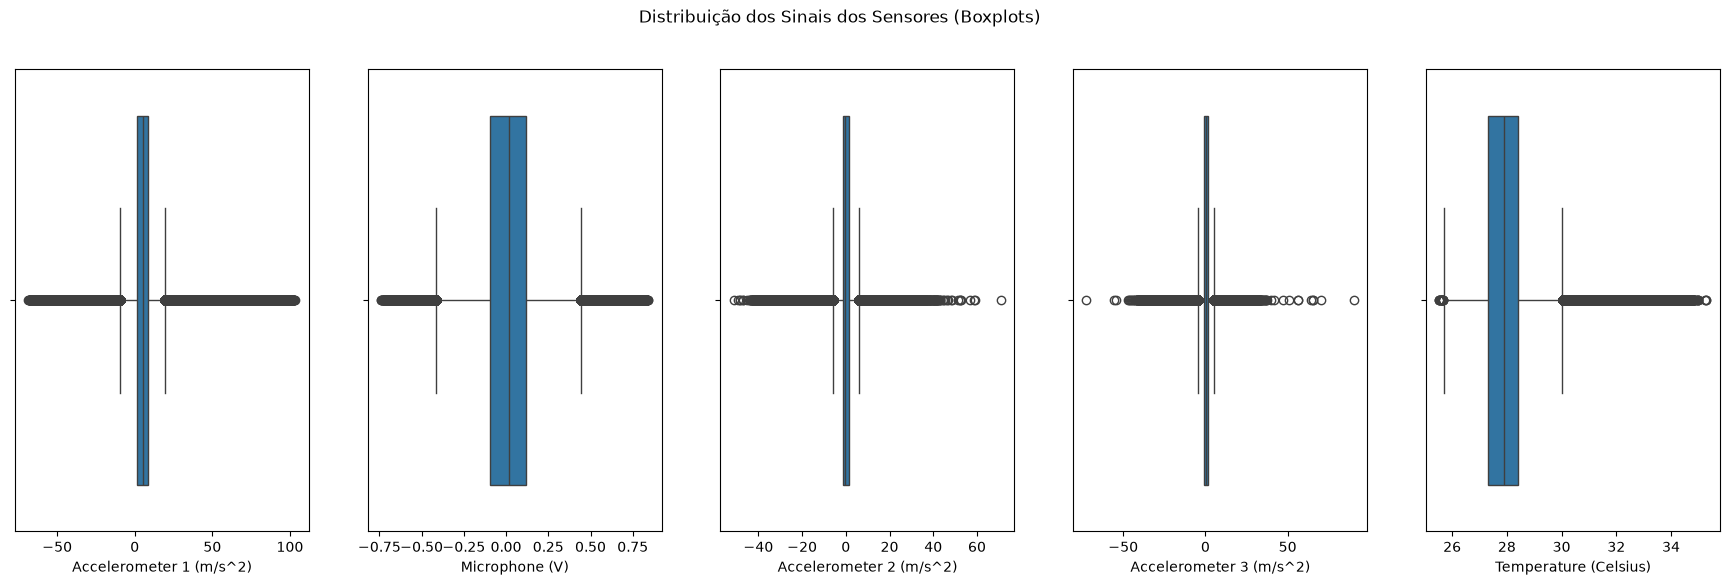

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Distribuição dos Sinais dos Sensores (Boxplots)')

sns.boxplot(ax=axes[0], x=df_full['Accelerometer 1 (m/s^2)'])
sns.boxplot(ax=axes[1], x=df_full['Microphone (V)'])
sns.boxplot(ax=axes[2], x=df_full['Accelerometer 2 (m/s^2)'])
sns.boxplot(ax=axes[3], x=df_full['Accelerometer 3 (m/s^2)'])
sns.boxplot(ax=axes[4], x=df_full['Temperature (Celsius)'])

# Salvar a figura
plt.savefig('../images/boxplots_sensores.png', dpi=300, bbox_inches='tight')

plt.show()

O gráfico acima demonstra que os acelerômetros apresentam distribuições amplas, com caudas longas, o que pode apontar para vibração intensa do motor em operação. O Accelerometer 1 mostra amplitude ainda maior. O microfone, por outro lado, possui baixa amplitude e distribuição estreita, característica de ruído suave. Já a temperatura exibe uma faixa extremamente compacta, indicando estabilidade térmica.<br>

Vamos agora imprimir o histograma das variáveis.<br>
O histograma irá permitir observar como os valores de cada sensor se distribuem ao longo do tempo, revalando padrões dos sinais encontrados.

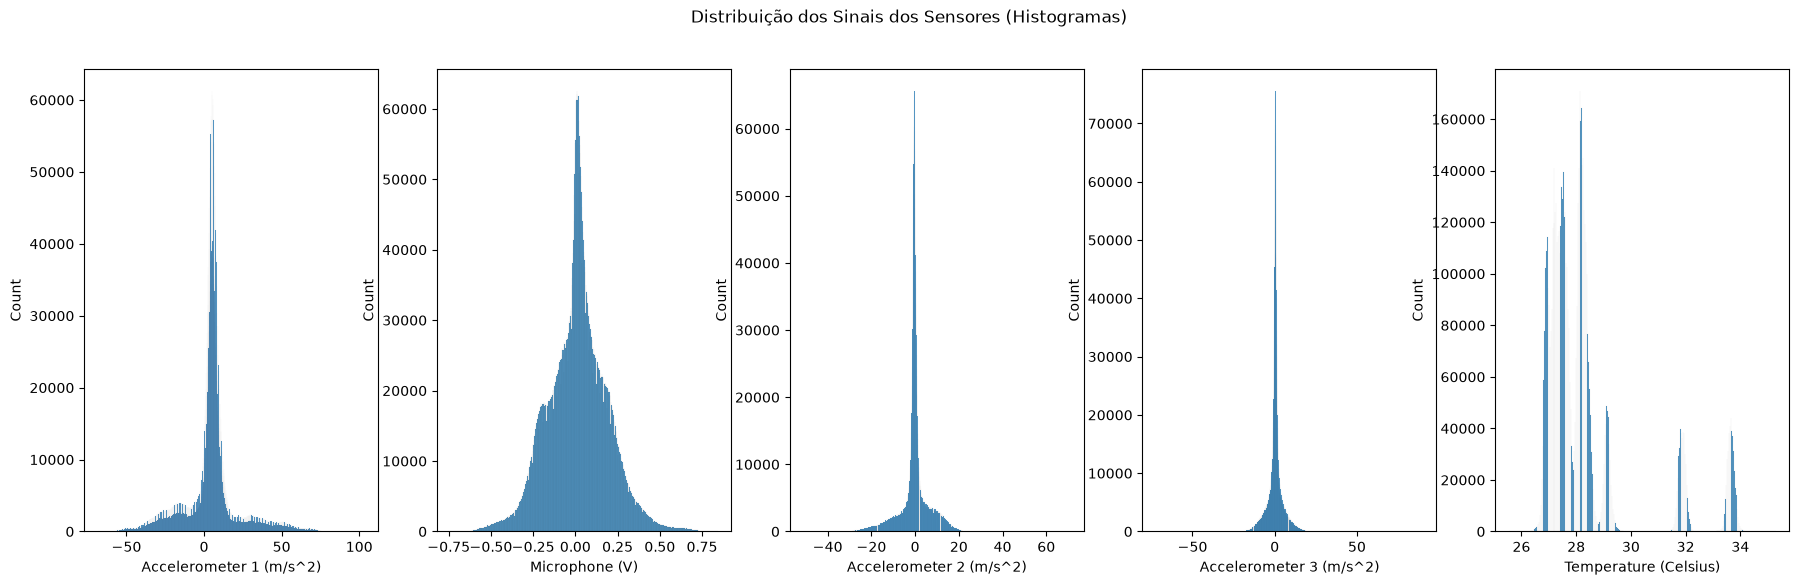

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Distribuição dos Sinais dos Sensores (Histogramas)')

sns.histplot(ax=axes[0], x=df_full['Accelerometer 1 (m/s^2)'])
sns.histplot(ax=axes[1], x=df_full['Microphone (V)'])
sns.histplot(ax=axes[2], x=df_full['Accelerometer 2 (m/s^2)'])
sns.histplot(ax=axes[3], x=df_full['Accelerometer 3 (m/s^2)'])
sns.histplot(ax=axes[4], x=df_full['Temperature (Celsius)'])

# Salvar a figura
plt.savefig('../images/histogramas_sensores.png', dpi=300, bbox_inches='tight')

plt.show()

Os acelerometros temos distribuições amplas e concentradas em torno de zero, caudas longas, que pode reafirmar a presença de vibração intensa. <br>
O microfone já demonstra uma distribução próxima de zero. Não apresentando sinais abruptos.<br>
Temperatura apresenta distribuição em diversos picos, mas esses picos apresentam um comportamento de faixa praticamente estável. Como os dados são temporais o gráfico em questão para temperatura apresenta pouca interpretabilidade.

Vamos agora visualizar os sinais no domínio do tempo. O gráfico de tempo permite observar o comportamento dos sensores, revelando oscilações, padrões de vibração, ruído acústico e a estabilidade térmica do motor.<br>
Temos a frequência de amostra de 42000 Hz, e sabendo que o sensor registra 42000 pontos por segundo, com o desejo de visualizar 0.1 do sinal, multiplicamos o valor de 0.1 por 42000 pontos, o que resultou no segmento de 4200.<br>

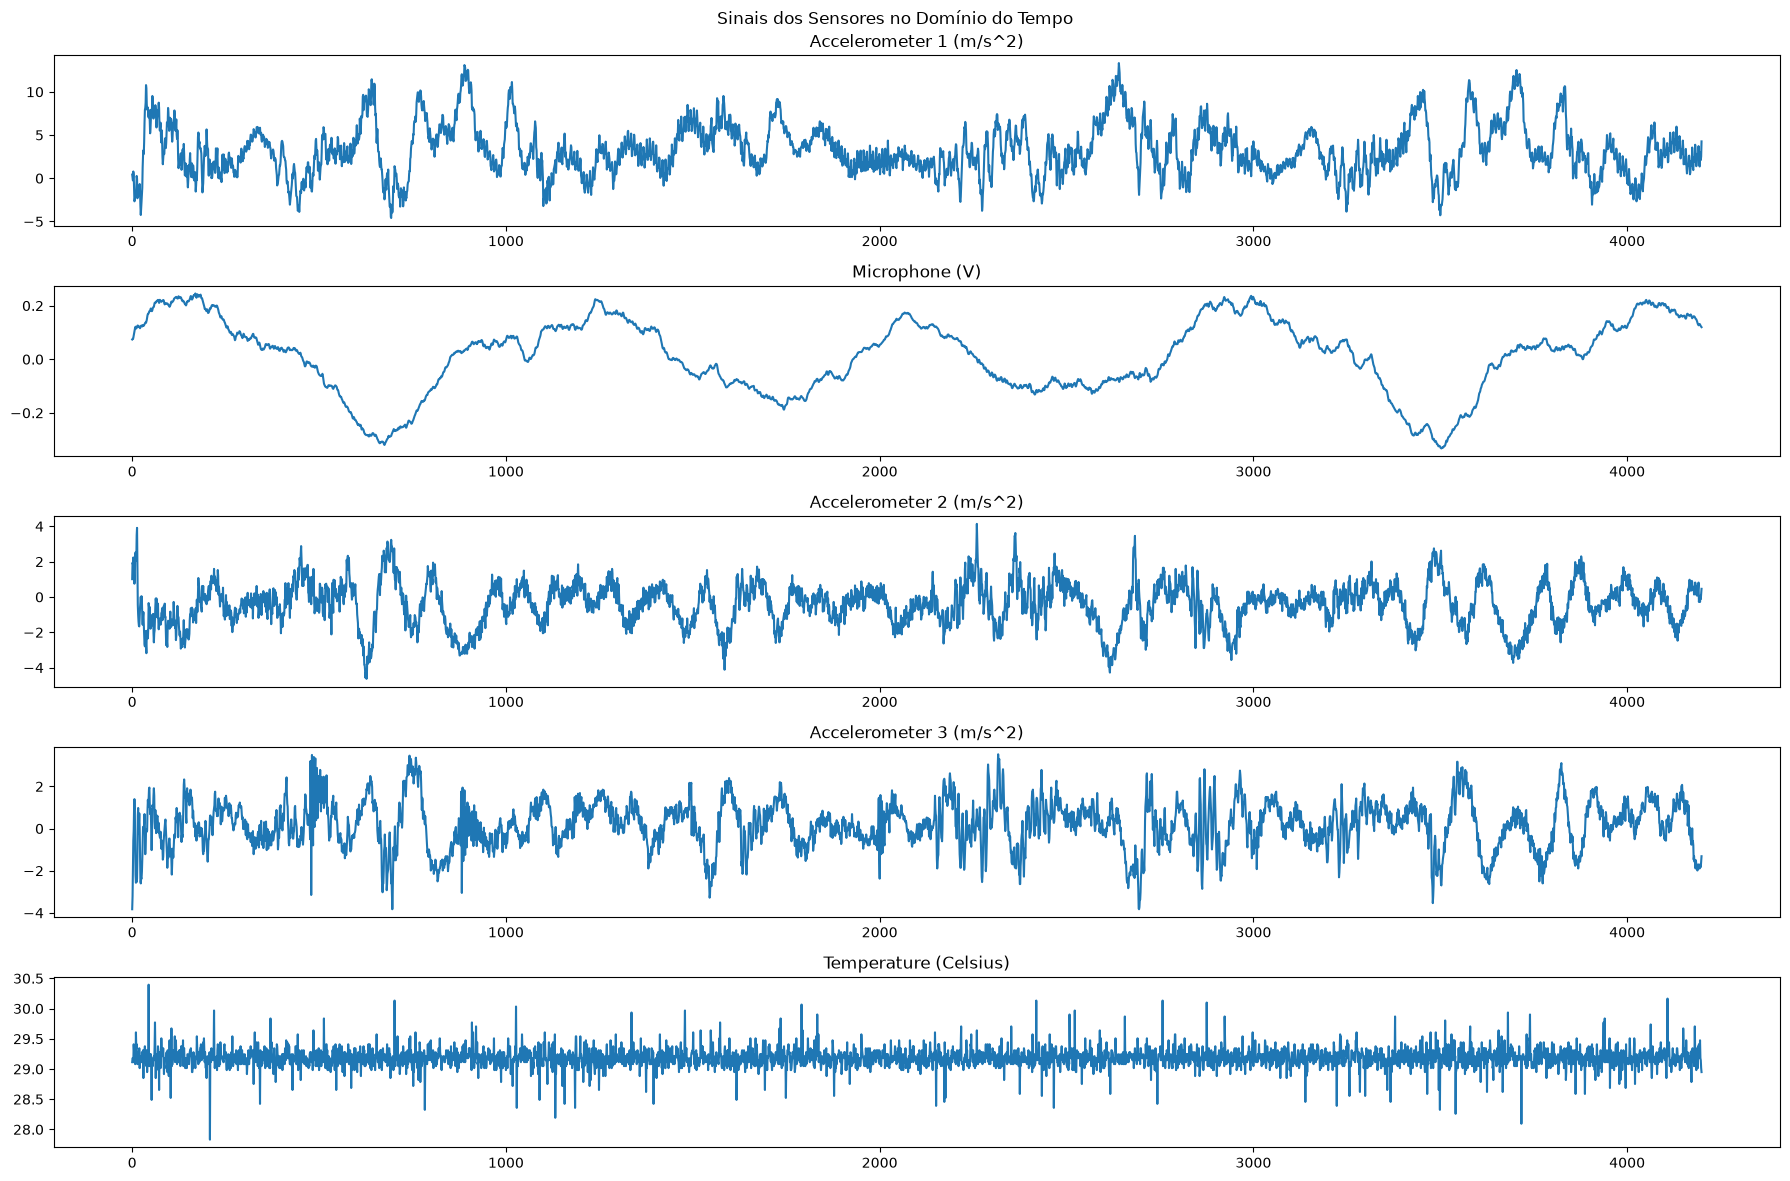

In [16]:
fig, axes = plt.subplots(5, 1, figsize=(18, 12))
fig.suptitle('Sinais dos Sensores no Domínio do Tempo')

segment = 4200

axes[0].plot(df_full['Accelerometer 1 (m/s^2)'][:segment])
axes[0].set_title('Accelerometer 1 (m/s^2)')

axes[1].plot(df_full['Microphone (V)'][:segment])
axes[1].set_title('Microphone (V)')

axes[2].plot(df_full['Accelerometer 2 (m/s^2)'][:segment])
axes[2].set_title('Accelerometer 2 (m/s^2)')

axes[3].plot(df_full['Accelerometer 3 (m/s^2)'][:segment])
axes[3].set_title('Accelerometer 3 (m/s^2)')

axes[4].plot(df_full['Temperature (Celsius)'][:segment])
axes[4].set_title('Temperature (Celsius)')

plt.tight_layout()
plt.savefig('../images/temporal_sensores.png', dpi=300, bbox_inches='tight')
plt.show()


O eixo X do gráfico representa a quantidade de amostras até a janela de 4200, definida pelo segmento. No eixo Y respectivamente aceleração (m/s²), tensão (V), e graus Celsius.<br>
Os acelerometros apresentam variações rápidas e continuas, sendo o Accelerometer 1 que apresenta amplitudade maior.<br>
O microfone aprsenta variações oscilações pequenas. E no caso da temperatura pode-se perceber quaser uma estabilidade.<br>

**Observação**: As etapas seguintes foram feitas com o Auxilio de IA Generativa (CoPilot).

A FFT é um algoritmo que transforma um sinal do domínio do tempo (como o que você acabou de plotar) para o domínio da frequência.<br>
Ela responde à pergunta:
- Quais frequências existem dentro do sinal e com que intensidade?

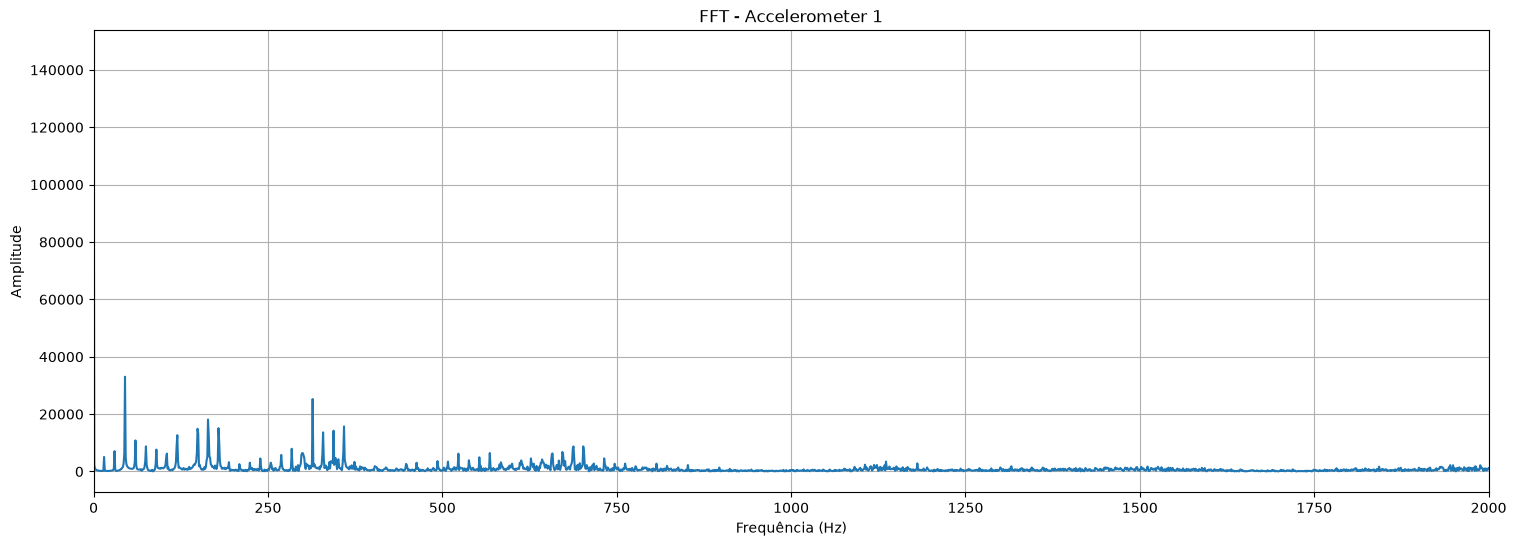

In [17]:
# Selecionar 1 segundo de dados (42.000 amostras)
segment = df_full['Accelerometer 1 (m/s^2)'][:42000]

# FFT
fft_vals = np.abs(np.fft.rfft(segment))
freqs = np.fft.rfftfreq(len(segment), 1/42000)

# Plot
plt.figure(figsize=(18, 6))
plt.plot(freqs, fft_vals)
plt.title('FFT - Accelerometer 1')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 2000)  # opcional: limita o eixo para ver melhor
plt.grid(True)
plt.show()

A FFT mostra como a energia do sinal se distribui ao longo das frequências. No Accelerometer 1, observamos picos concentrados nas baixas frequências, especialmente abaixo de 500 Hz, indicando componentes mecânicas como harmônicos de rotação e vibração fundamental do eixo. À medida que a frequência aumenta, a amplitude cai rapidamente, comportamento típico de sinais de vibração onde a maior parte da energia está associada ao movimento periódico do motor.<br>

Nas frequências acima de aproximadamente 1000 Hz, o espectro se torna mais plano, representando ruído de fundo e pequenas irregularidades do sistema. Esse padrão confirma que o sensor captura corretamente tanto os componentes mecânicos quanto o ruído natural do processo, e fornece informações essenciais para features como pico dominante e energia em bandas de frequência.<br>

Vamos repetir o gráfico para os acelerometro 2.

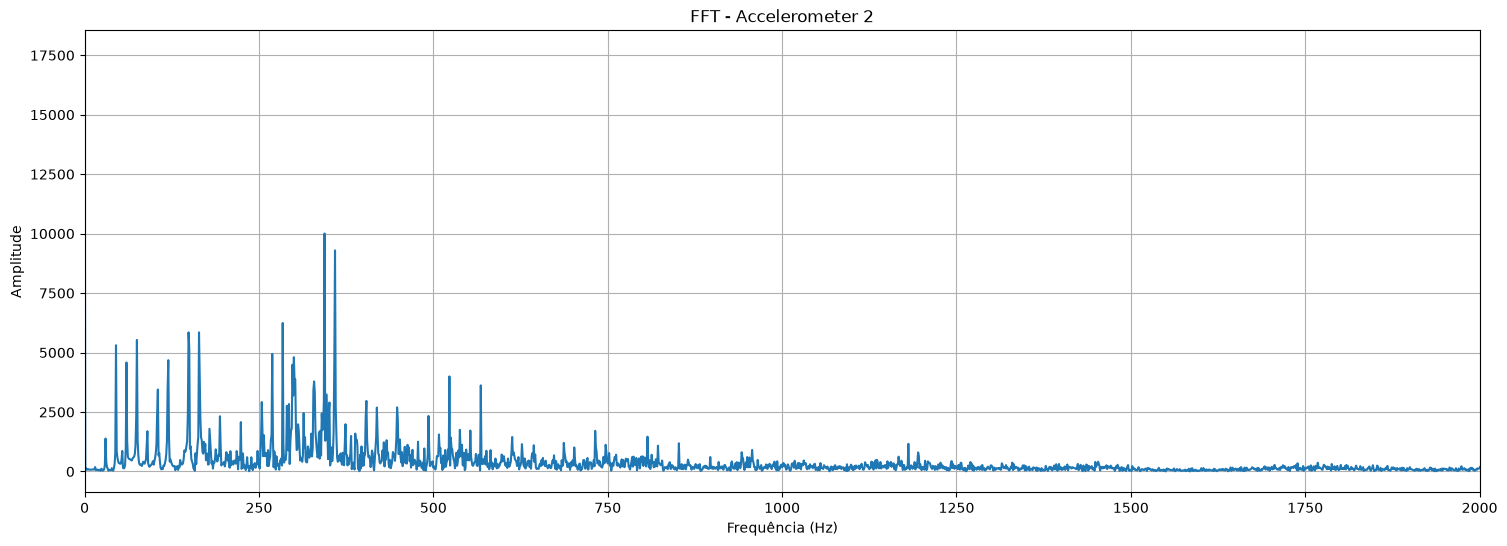

In [18]:
# Selecionar 1 segundo de dados (42.000 amostras)
segment = df_full['Accelerometer 2 (m/s^2)'][:42000]

# FFT
fft_vals = np.abs(np.fft.rfft(segment))
freqs = np.fft.rfftfreq(len(segment), 1/42000)

# Plot
plt.figure(figsize=(18, 6))
plt.plot(freqs, fft_vals)
plt.title('FFT - Accelerometer 2')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 2000)
plt.grid(True)
plt.show()


O espectro do Accelerometer 2 também apresenta picos concentrados nas baixas frequências, principalmente entre 100 e 400 Hz, indicando componentes mecânicas relacionadas à rotação do motor e seus harmônicos. A amplitude é menor que a do Accelerometer 1, sugerindo que este sensor está em uma posição com menor acoplamento ao ruído elétrico ou menor intensidade de vibração.<br>

A função extract_features recebe uma janela de sinal e calcula um conjunto de características no domínio do tempo e da frequência. No domínio temporal, ela extrai estatísticas fundamentais como média, desvio padrão, RMS, skewness, kurtosis, além de valores máximo, mínimo e energia do sinal.

In [28]:
# -----------------------------
# 1. Função de extração de features
# -----------------------------
def extract_features(window, fs=42000):
    mean_val = window.mean()
    std_val = window.std()
    rms_val = np.sqrt(np.mean(window**2))

    skew_val = ((window - mean_val)**3).mean() / std_val**3
    kurt_val = ((window - mean_val)**4).mean() / std_val**4

    max_val = window.max()
    min_val = window.min()
    energy_val = np.sum(window**2)

    fft_vals = np.abs(np.fft.rfft(window))
    freqs = np.fft.rfftfreq(len(window), 1/fs)

    peak_amp = fft_vals.max()
    band_energy = fft_vals[(freqs >= 0) & (freqs <= 500)].sum()

    return pd.Series({
        'mean': mean_val,
        'std': std_val,
        'rms': rms_val,
        'skew': skew_val,
        'kurt': kurt_val,
        'max': max_val,
        'min': min_val,
        'energy': energy_val,
        'peak_amp': peak_amp,
        'band_energy': band_energy
    })

Após definir a função extract_features, o próximo passo é aplicá‑la às janelas do sinal. Cada janela representa um intervalo de 1 segundo (42.000 amostras) e é processada individualmente. Para cada janela, extraímos as 10 features no domínio do tempo e da frequência, formando uma linha do dataset final. Ao repetir esse processo para todas as janelas e sensores, construímos a base de dados que será usada para treinar os modelos de classificação.

In [29]:
# -----------------------------
# 2. Criar janelas
# -----------------------------
def create_windows(signal, window_size=42000):
    windows = []
    for start in range(0, len(signal), window_size):
        end = start + window_size
        if end <= len(signal):
            windows.append(signal[start:end])
    return windows


Aplicar a função de features em cada janela

In [30]:
# -----------------------------
# 3. Extrair classe do nome do arquivo
# -----------------------------
def get_class_from_filename(file_path):
    name = os.path.basename(file_path)      # B_R_1_0.csv
    name_no_ext = name.split('.')[0]        # B_R_1_0
    parts = name_no_ext.split('_')          # ['B','R','1','0']
    classe = parts[0] + "_" + parts[1]      # B_R
    return classe

In [31]:
# -----------------------------
# 4. Processar arquivo
# -----------------------------
def process_file(file_path):
    df_full = pd.read_csv(file_path)
    classe = get_class_from_filename(file_path)

    sensores = [
        'Accelerometer 1 (m/s^2)',
        'Microphone (V)',
        'Accelerometer 2 (m/s^2)',
        'Accelerometer 3 (m/s^2)',
        'Temperature (Celsius)'
    ]

    all_features = []

    for sensor in sensores:
        signal = df_full[sensor].values
        windows = create_windows(signal)

        for w in windows:
            feats = extract_features(w)
            feats['sensor'] = sensor
            feats['label'] = classe
            all_features.append(feats)

    return pd.DataFrame(all_features)

In [32]:
# -----------------------------
# 5. Montar dataset final
# -----------------------------
base = r"../data"
files = [os.path.join(base, f) for f in os.listdir(base) if f.endswith(".csv")]

In [33]:
df_total = pd.concat([process_file(f) for f in files], ignore_index=True)

Com a criação das funções vamos criar os gráficos para análise.

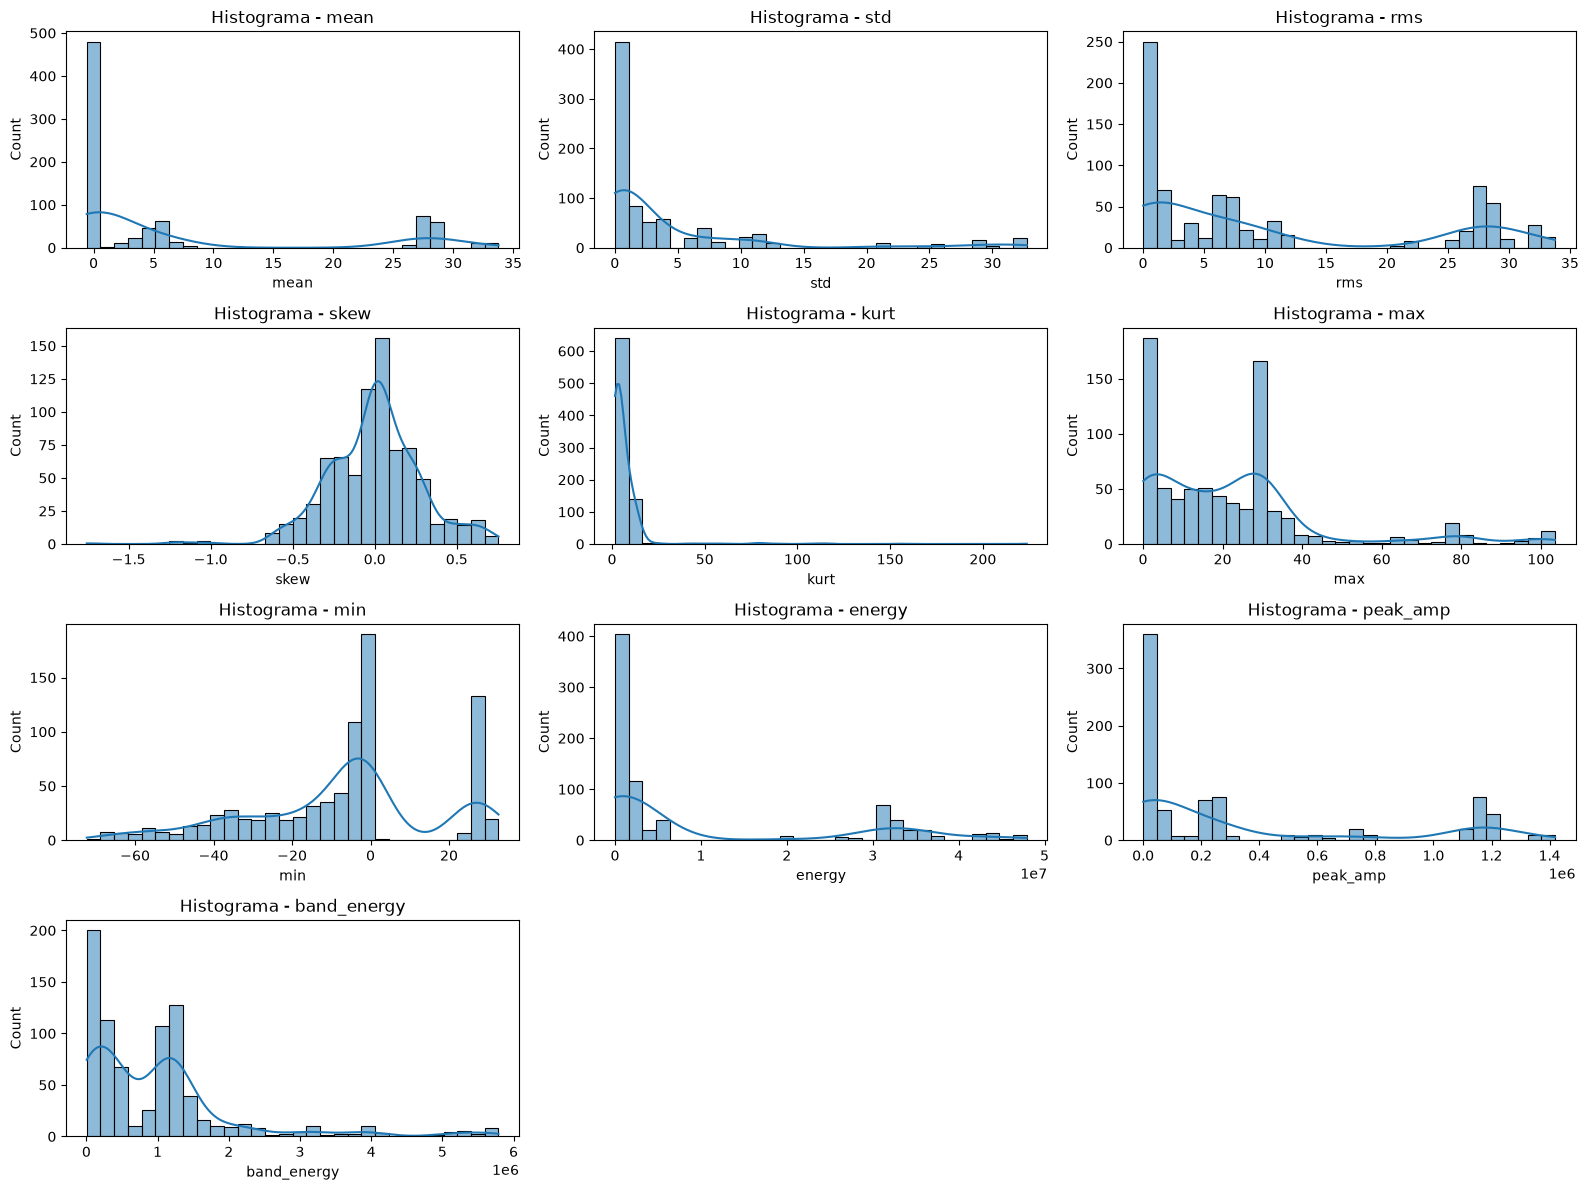

In [34]:
features = [
    'mean', 'std', 'rms', 'skew', 'kurt',
    'max', 'min', 'energy', 'peak_amp', 'band_energy'
]

plt.figure(figsize=(16, 12))

for i, feat in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df_total[feat], kde=True, bins=30)
    plt.title(f'Histograma - {feat}')

plt.tight_layout()
plt.show()


Os histogramas das features mostram claramente como cada atributo extraído do sinal se distribui ao longo das janelas. Observa‑se que algumas variáveis, como mean, std e rms, apresentam distribuições mais concentradas, indicando comportamento estável e pouca variação entre janelas. Já outras, como energy, peak_amp e band_energy, exibem caudas longas e maior dispersão, sugerindo que capturam eventos mais intensos ou variações abruptas no sinal. Essa diferença de comportamento é importante porque revela quais features são mais sensíveis às mudanças no estado do motor.<br>

Além disso, features como skew e kurt apresentam distribuições assimétricas e valores extremos, o que é esperado em sinais vibroacústicos, onde irregularidades e picos podem ocorrer. Esses padrões ajudam a identificar possíveis outliers e a avaliar se alguma transformação (como normalização ou padronização) será necessária antes da modelagem. Em conjunto, os histogramas fornecem uma visão inicial da “saúde estatística” das features e ajudam a entender quais delas têm maior potencial para diferenciar as classes do problema.<br>

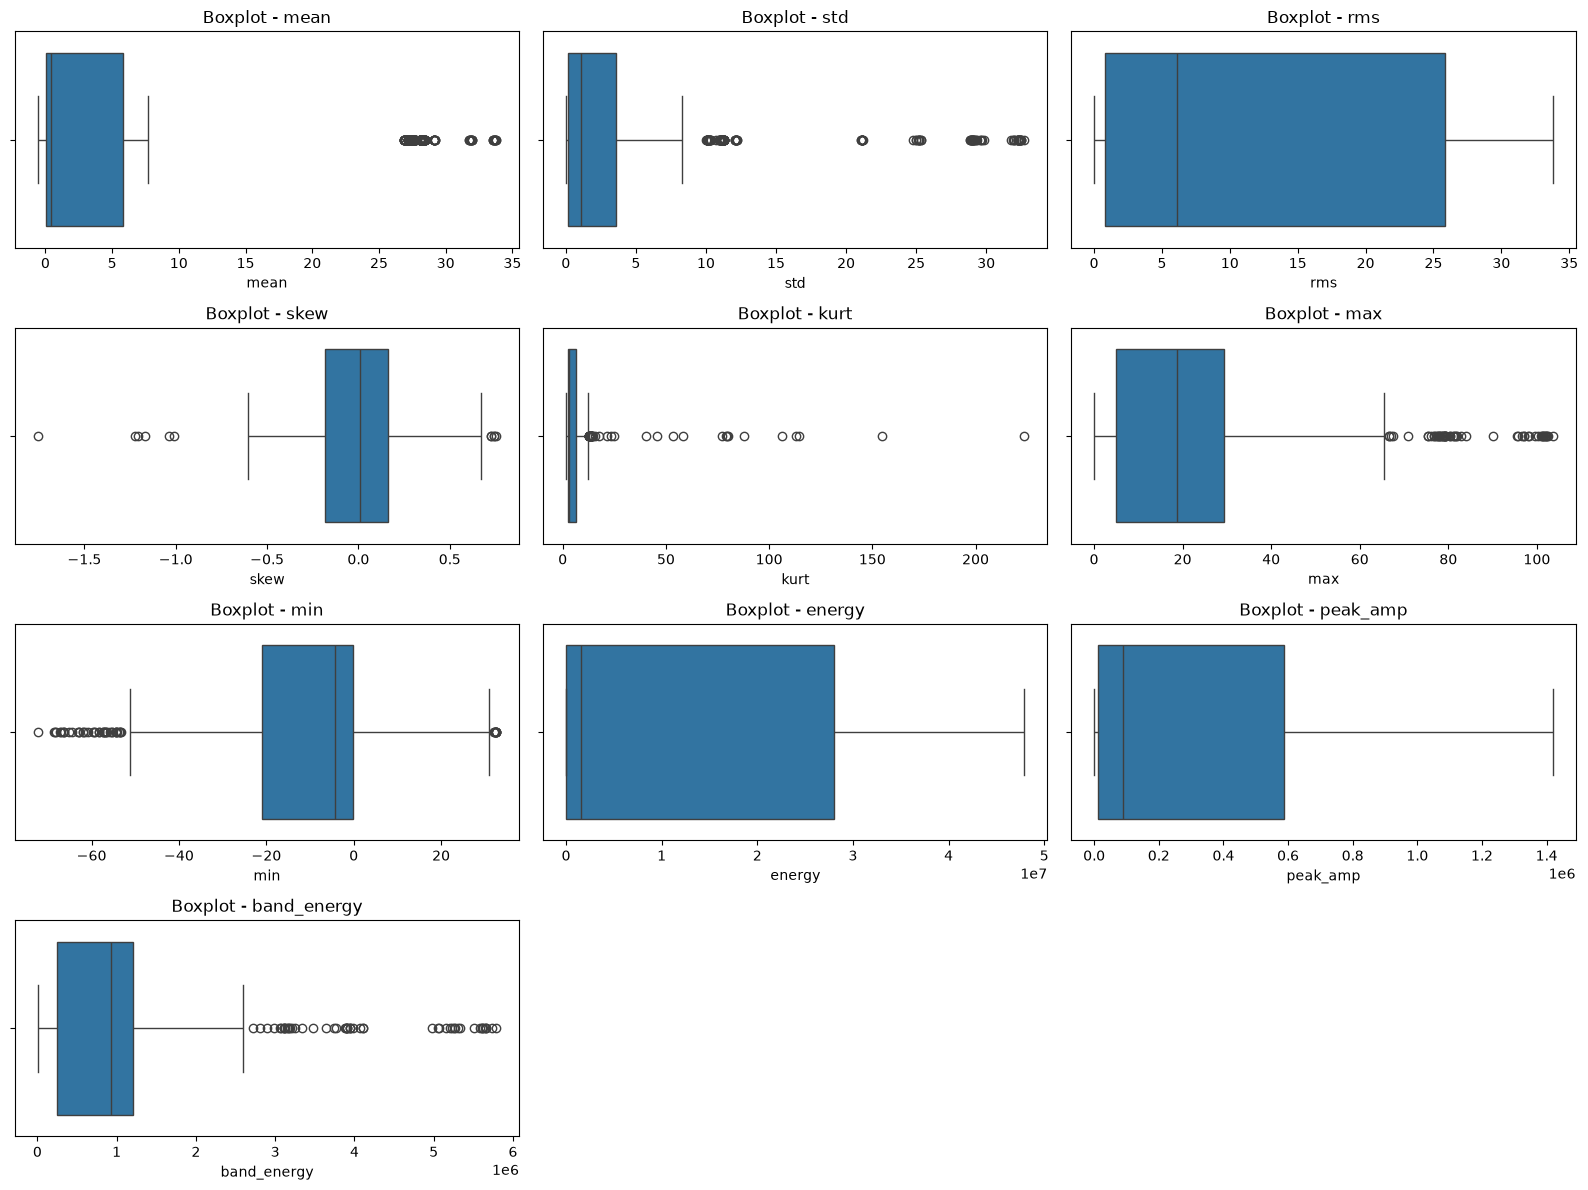

In [35]:
plt.figure(figsize=(16, 12))

for i, feat in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df_total[feat])
    plt.title(f'Boxplot - {feat}')

plt.tight_layout()
plt.show()


Os boxplots revelam a amplitude e a presença de outliers em cada feature extraída do sinal. Observa‑se que variáveis como mean, std e rms apresentam caixas mais compactas, indicando menor variabilidade entre janelas e comportamento mais estável. Em contraste, features como energy, peak_amp e band_energy exibem whiskers longos e pontos dispersos, evidenciando maior sensibilidade a picos e eventos de alta intensidade no sinal vibroacústico. Esse padrão é esperado em sinais reais de motores, onde pequenas irregularidades podem gerar valores extremos.<br>

Além disso, os boxplots ajudam a identificar quais features podem exigir tratamento adicional antes da modelagem. A presença de outliers em skew e kurt, por exemplo, sugere que essas métricas capturam assimetrias e irregularidades importantes, mas também podem introduzir instabilidade se não forem normalizadas ou padronizadas. No conjunto, os boxplots complementam os histogramas ao mostrar não apenas a distribuição, mas também a dispersão e a robustez das features, facilitando decisões de engenharia de atributos e seleção de variáveis.<br>

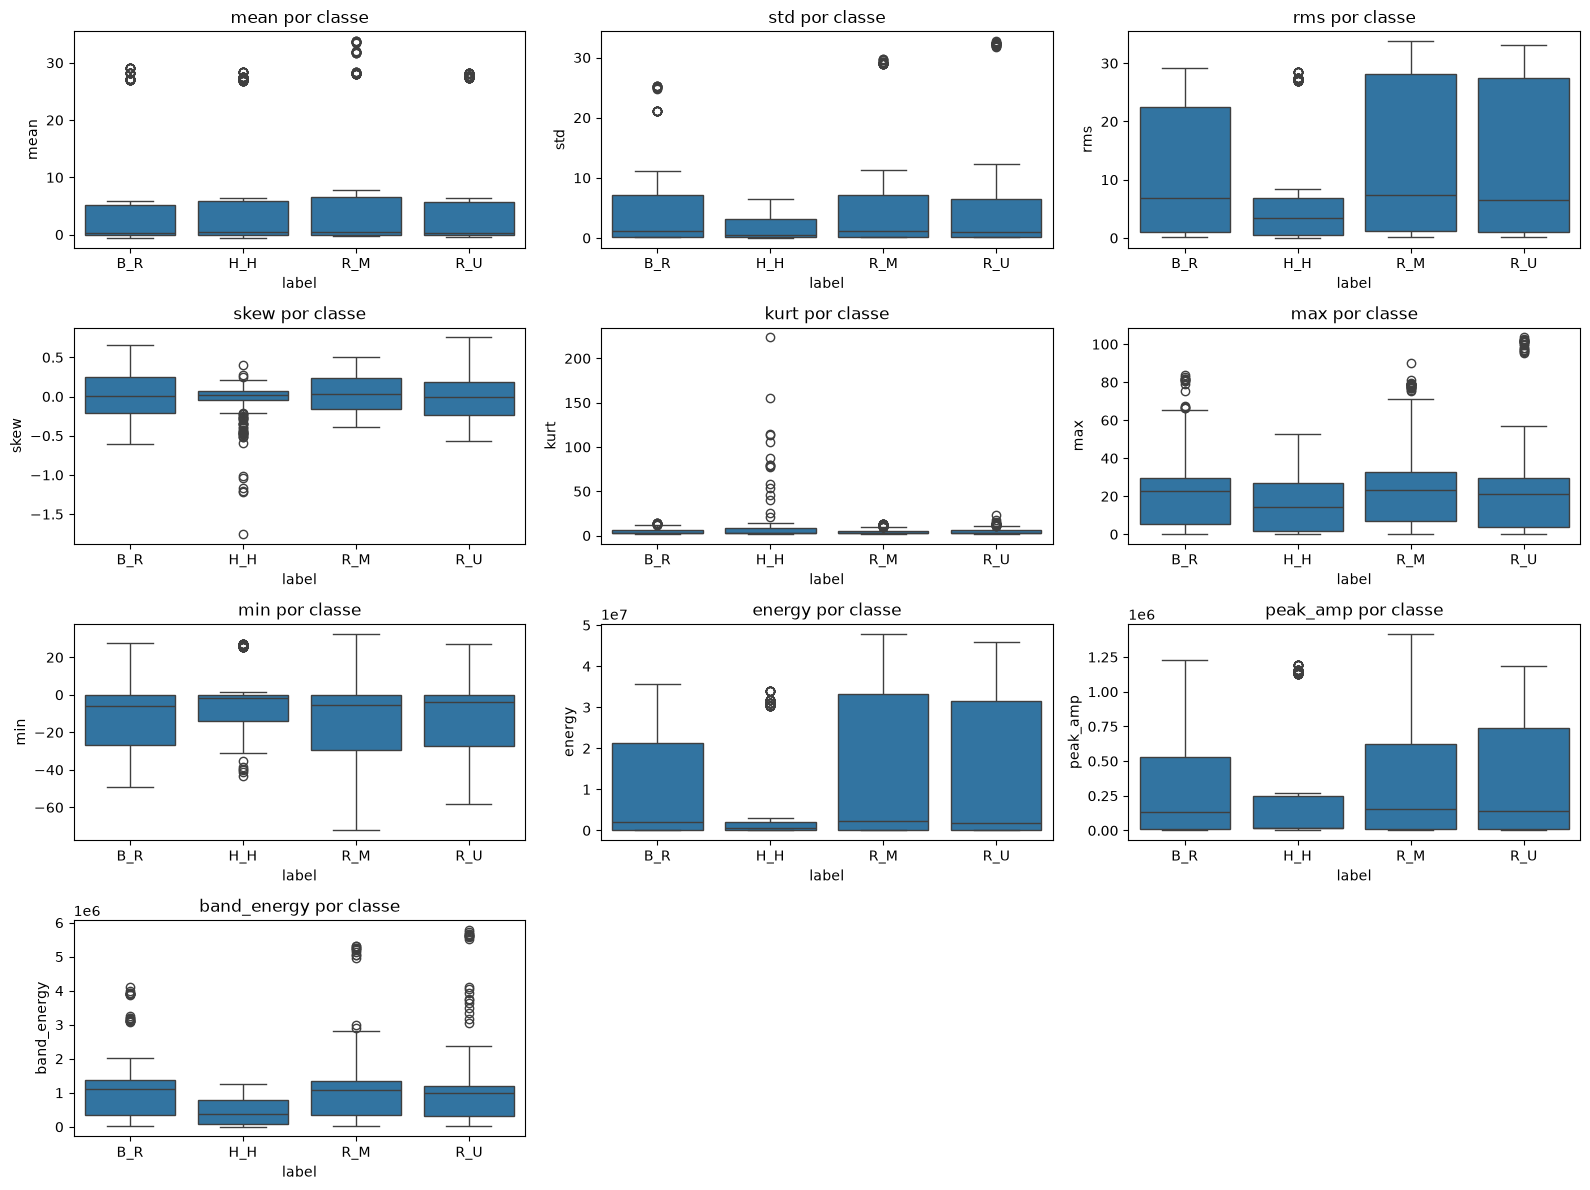

In [36]:
plt.figure(figsize=(16, 12))

for i, feat in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=df_total, x='label', y=feat)
    plt.title(f'{feat} por classe')

plt.tight_layout()
plt.show()


Os boxplots por classe mostram como cada feature se comporta nas quatro condições do motor (B_R, H_H, R_M e R_U). Observa‑se que algumas features, como mean, std e rms, apresentam diferenças claras entre as classes, indicando que essas métricas capturam variações reais no estado do equipamento. Já outras, como min e max, exibem maior sobreposição entre as classes, sugerindo que podem ter menor poder discriminativo isoladamente. A presença de caixas mais altas ou mais baixas entre classes revela quais atributos respondem melhor às mudanças no comportamento vibroacústico.<br>

Além disso, features como energy, peak_amp e band_energy mostram dispersão elevada e diferenças marcantes entre as classes, reforçando que são boas candidatas para classificação. A distribuição distinta dessas features indica que cada condição do motor gera padrões específicos de intensidade e frequência no sinal. Esses resultados são fundamentais para a etapa de seleção de features, pois evidenciam quais atributos realmente ajudam a separar as classes e quais podem ser descartados ou transformados.<br>

### 3.3 Random Forest

A etapa seguinte consiste em preparar os dados para modelagem, separando as features e os rótulos, dividindo o conjunto em treino e teste e aplicando normalização quando necessário. Com os dados prontos, utilizamos dois modelos complementares: Random Forest, que é robusto, não exige padronização e revela a importância das features, e Logistic Regression, que funciona como um baseline linear e ajuda a avaliar se o problema apresenta separação simples entre classes. Juntos, esses modelos fornecem uma primeira avaliação sólida da capacidade das features em distinguir os diferentes estados do motor.

In [38]:
X = df_total.drop(columns=['label', 'sensor'])
y = df_total['label']

# Divide em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalização (apenas para Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Acurácia - Random Forest:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Acurácia - Random Forest: 0.95
[[36  0  1  3]
 [ 0 40  0  0]
 [ 0  0 39  1]
 [ 0  0  3 37]]
              precision    recall  f1-score   support

         B_R       1.00      0.90      0.95        40
         H_H       1.00      1.00      1.00        40
         R_M       0.91      0.97      0.94        40
         R_U       0.90      0.93      0.91        40

    accuracy                           0.95       160
   macro avg       0.95      0.95      0.95       160
weighted avg       0.95      0.95      0.95       160



Random Forest apresentou um desempenho muito sólido, com 95% de acurácia e excelente equilíbrio entre precision, recall e f1‑score nas quatro classes. A matriz de confusão mostra que o modelo quase não comete erros, especialmente nas classes H_H e R_M, que foram classificadas de forma praticamente perfeita. As poucas confusões aparecem entre B_R e R_U, o que é esperado, já que essas condições tendem a gerar padrões vibroacústicos mais semelhantes. 

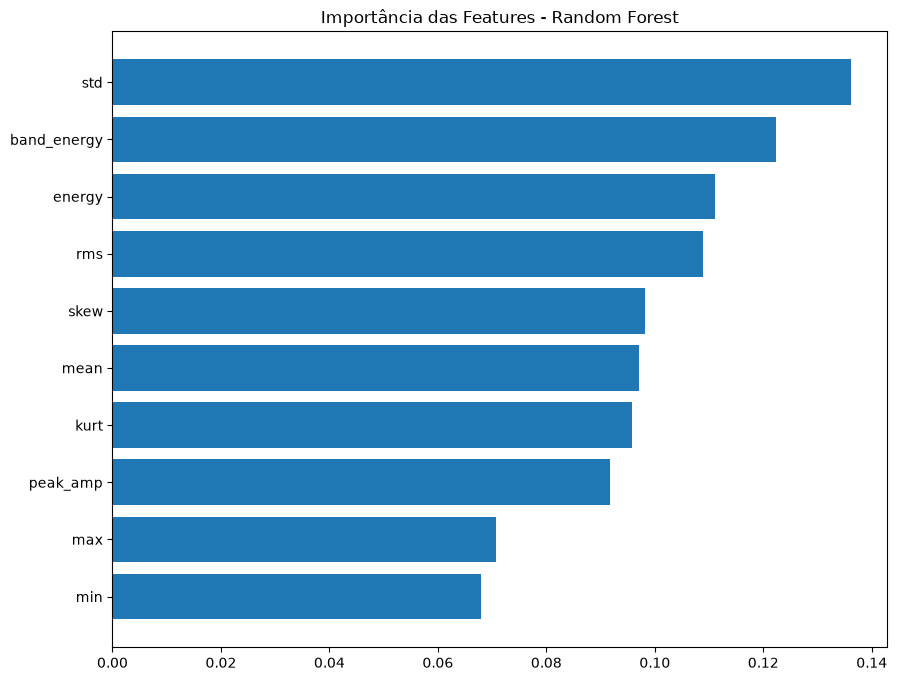

In [41]:
importances = rf.feature_importances_
feature_names = X.columns

sorted_idx = importances.argsort()

plt.figure(figsize=(10, 8))
plt.barh(feature_names[sorted_idx], importances[sorted_idx])
plt.title("Importância das Features - Random Forest")
plt.show()


Observa‑se que std, band_energy, energy e rms aparecem como as variáveis mais influentes, indicando que medidas de variação e intensidade do sinal são fundamentais para distinguir os estados do motor. Já features como min, max e peak_amp têm impacto menor, sugerindo que valores extremos isolados não carregam tanta informação discriminativa quanto métricas estatísticas mais robustas.

### 3.4 Logistic Regression

In [45]:
lr = LogisticRegression(
    max_iter=500,
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Acurácia - Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Acurácia - Logistic Regression: 0.40625
[[15 13  4  8]
 [ 2 31  7  0]
 [11 14 13  2]
 [ 6 15 13  6]]
              precision    recall  f1-score   support

         B_R       0.44      0.38      0.41        40
         H_H       0.42      0.78      0.55        40
         R_M       0.35      0.33      0.34        40
         R_U       0.38      0.15      0.21        40

    accuracy                           0.41       160
   macro avg       0.40      0.41      0.38       160
weighted avg       0.40      0.41      0.38       160



o resultado da Regressão Logística mostra que o modelo não conseguiu capturar bem as relações entre as features e as classes, alcançando apenas 40% de acurácia e apresentando muita confusão entre todas as categorias. Embora a classe H_H tenha um recall mais alto, as demais apresentam desempenho fraco, indicando que a separação entre os estados do motor não é linear. 

<Figure size 600x600 with 0 Axes>

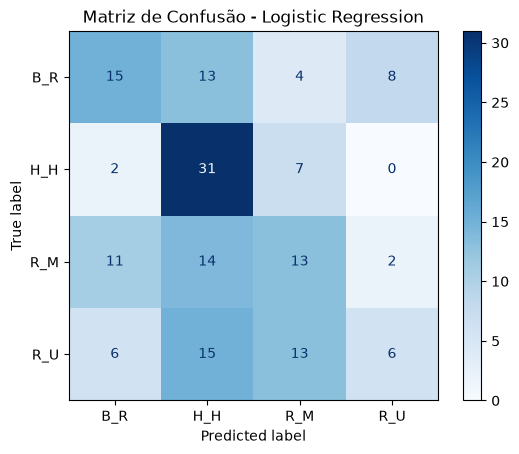

In [47]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão - Logistic Regression")
plt.show()

As classes R_M e R_U foram especialmente problemáticas, com forte dispersão das previsões e baixa capacidade de identificar corretamente seus padrões. Mesmo a classe H_H, que teve o melhor desempenho relativo, ainda mostra confusões significativas. Esse comportamento confirma que a relação entre as features e os estados do motor não é linear, tornando a Regressão Logística inadequada para capturar a complexidade do sinal vibroacústico.

## 4. Módulo 2: Softsensor de Temperatura

O módulo 2 seria dedicado a transformar os modelos iniciais em versões mais fortes, otimizadas e prontas para uso real. Ele normalmente envolve três frentes principais: primeiro, aplicar tuning de hiperparâmetros, usando técnicas como Grid Search ou Random Search para encontrar as melhores configurações do Random Forest e da Logistic Regression; depois, testar modelos mais avançados, como SVM, Gradient Boosting, XGBoost ou até redes neurais, avaliando se eles capturam padrões mais complexos do sinal; e por fim, consolidar tudo em um pipeline de classificação, com normalização, seleção de features e o modelo final integrado, garantindo reprodutibilidade e facilidade de implantação. Em resumo, o módulo 2 transforma os resultados iniciais em um sistema otimizado e robusto para classificação dos estados do motor.

## Conclusão

## Bibliografia

<p align = 'justify'>
<a name="id_1">[1]</a> Biblioteca OS Documentação do Python. Disponível em <'https://docs.python.org/3/library/os.html'>. Acesso em 23/08/2026.</p>

<p align = 'justify'>
<a name="id_2">[2]</a> Biblioteca do Pandas. Disponível em <'https://pandas.pydata.org/docs/getting_started/overview.html'>. Acesso em 23/08/2026.</p>

<p align = 'justify'>
<a name="id_3">[3]</a> Biblioteca Numpy. Disponível em <'https://numpy.org/doc/stable/'>. Acesso em 23/08/2026.</p>

<p align = 'justify'>
<a name="id_4">[4]</a> Biblioteca Searborn. Disponível em <'https://seaborn.pydata.org'>. Acesso em 23/08/2026.</p>

<p align = 'justify'>
<a name="id_5">[5]</a> Biblioteca Matplotlib. Disponível em <'https://matplotlib.org'>. Acesso em 23/08/2026.</p>

<p align = 'justify'>
<a name="id_6">[6]</a> Biblioteca do Scikit-Learn. Disponível em <'https://scikit-learn.org/stable/#'>. Acesso em 23/08/2026.</p>